# Setup

In [1]:
# Only needed for VS Code - change cwd to the notebook's directory for VS Code 
import os

try:
    notebook_path = globals()['__vsc_ipynb_file__']
    notebook_dir = os.path.dirname(notebook_path)
    os.chdir(notebook_dir)
    print(f"Changed directory to: {notebook_dir}")
except:
    print("ERROR. Could not find notebook path. Running from:", os.getcwd())

Changed directory to: /lustre/groups/imm01/workspace/yang/DextraDemixer/experiments/synthetic_benchmark


In [2]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wilcoxon

import sys
sys.path.append('../../')
from dextrademixer.utils.utils import mean_ci_t_interval, aggregate_csv

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

%load_ext autoreload
%autoreload 2

/opt/conda/envs/dextrademixer/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Figure settings
FIGURE_PATH = '../../figures/Figure2'
os.makedirs(FIGURE_PATH, exist_ok=True)

sns.reset_defaults()
global_settings = {'font.size': 12, 'axes.titlesize': 'large', 'axes.labelsize': 'medium', 'xtick.labelsize': 'medium', 'ytick.labelsize': 'medium', 
                   'legend.fontsize': 'medium', 'figure.titlesize': 'large', 'figure.figsize': (3, 2.5), 'figure.dpi': 100, 'savefig.dpi': 300, 
                   'savefig.bbox': 'tight', 'savefig.transparent': True, 'axes.spines.top': False, 'axes.spines.right': False, }
plt.rcParams.update(global_settings)

hue_order = ['BEAM', 'DextraDemixer', 'DextraDemixer+neg.', 'DextraDemixer+clone', 'DextraDemixer+neg.+clone', ]
palette = {'ITRAP': "#ffa52e", 'ICON': "#ffeb11", 'BEAM': "#02c102", 
           'DextraDemixer': "#24c8c8", 'DextraDemixer+neg.': "#0f83b8", 'DextraDemixer+clone': "#0A44D5", 'DextraDemixer+neg.+clone': "#8900bf", 
           'DextraDemixer(+clone)': "#0A44D5", 'DextraDemixer+neg.(+clone)': "#8900bf",  # Scaling colors
           }

# Names were changed for the manuscript
naming_dict = {'sim_total_cells': 'Total cell count', 'sim_binding_ratio': 'Fraction of binders', 'sim_mean_inc': 'Signal-to-noise ratio'}

In [4]:
EXPERIMENT_PATH = 'benchmarks/synth_benchmark'
RESULTS_PATH = 'results'
os.makedirs(RESULTS_PATH, exist_ok=True)
RERUN = False  # True: Rerun data loading (requires Zenodo data), False: Load from preprocessed csv, will run if agg_fp not found

In [5]:
df_bench_fp = os.path.join(RESULTS_PATH, 'results_benchmark.csv')
df_fdr_fp = os.path.join(RESULTS_PATH, 'results_FDR.csv')

if not os.path.exists(df_bench_fp) or not os.path.exists(df_fdr_fp):
    df_all = aggregate_csv(experiment_path=EXPERIMENT_PATH, rerun=RERUN, output_path=os.path.join(RESULTS_PATH, 'results_all.csv'), paths=['csv', ])

    def get_clean_posterior_config_name(x):
        prefix = 'median@' if x['clone_median_p'] and pd.notna(x['clone_median_p']) else ''
        if pd.isna(x['target_fdr']):
            core = f'T={x["threshold"]}'
        else:
            core = f'FDR={x["target_fdr"]}'
            if pd.notna(x['cred_intvl']):
                core += f',cred_intvl={x["cred_intvl"]}'            
        return prefix + core

    df_all['posterior_config_clean'] = df_all.apply(get_clean_posterior_config_name, axis=1)
    df_all['sim_num_binder'] = df_all['sim_binding_ratio'] * df_all['sim_total_cells']
    # Rename for manuscript
    df_all['model_config'] = df_all['model_config'].str.replace('control', 'neg.', regex=False)

    df_bench = df_all[df_all['posterior_config_clean'].isin(['median@T=0.5', 'T=0.5'])].copy()
    df_fdr = df_all[df_all['posterior_config_clean'].str.contains('FDR=')].copy()

    df_bench.to_csv(df_bench_fp, index=False)
    df_fdr.to_csv(df_fdr_fp, index=False)

else:
    df_bench = pd.read_csv(df_bench_fp)
    df_fdr = pd.read_csv(df_fdr_fp)

# Synthetic benchmark

## Performance and robustness

In [6]:
# Performance mean + 95% CI
df_bench[df_bench['posterior_config_clean'].isin(['T=0.5', 'median@T=0.5'])].groupby('model_config')['f1'].apply(mean_ci_t_interval, confidence=0.95)

model_config
BEAM                        0.666 [0.654, 0.678]
DextraDemixer               0.857 [0.848, 0.867]
DextraDemixer+clone         0.900 [0.891, 0.910]
DextraDemixer+neg.          0.868 [0.859, 0.877]
DextraDemixer+neg.+clone    0.912 [0.904, 0.921]
Name: f1, dtype: object

In [7]:
# Paired Wilcoxon signed-rank test between neighbors
df_sub = df_bench.copy()
df_sub = df_sub.sort_values(['model_config', 'sim_config'])
    
# Wilcoxon
for idx in range(len(hue_order) - 1):
    data_1 = df_sub[df_sub['model_config'] == hue_order[idx]]['f1'].values
    data_2 = df_sub[df_sub['model_config'] == hue_order[idx + 1]]['f1'].values
    stat, pval = wilcoxon(data_1, data_2)
    print(f"{hue_order[idx]} and {hue_order[idx + 1]}: stat={stat:.0f}, p-value={pval:.0e}")

BEAM and DextraDemixer: stat=187962, p-value=9e-237
DextraDemixer and DextraDemixer+neg.: stat=16819, p-value=6e-28
DextraDemixer+neg. and DextraDemixer+clone: stat=148584, p-value=5e-127
DextraDemixer+clone and DextraDemixer+neg.+clone: stat=5436, p-value=8e-22


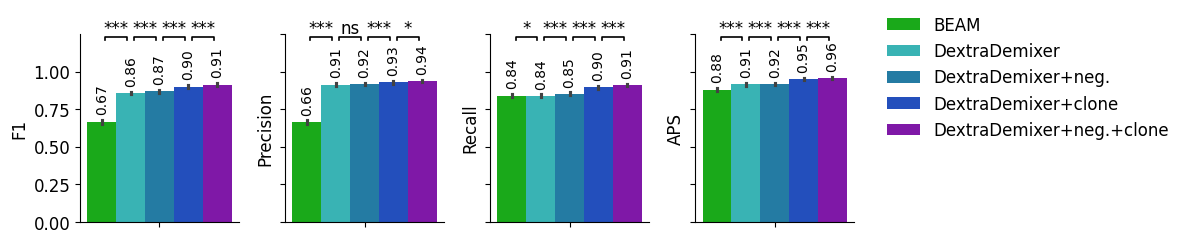

In [8]:
# Figure 2a - Classification performance across all synthetic benchmark configurations
fig = plt.figure(figsize=(2.2 * 4, 2.5))
i = 0
for metric in ['f1', 'precision', 'recall', 'aps']:
    i += 1        
    ax = plt.subplot(1, 4, i)

    df_sub = df_bench.copy()
    df_sub = df_sub.sort_values(['model_config', 'sim_config'])

    sns.barplot(data=df_sub, y=metric, hue='model_config', palette=palette, legend=i==4, hue_order=hue_order)
    if ax.get_legend():
        ax.get_legend().remove()
        
    plt.ylabel(metric.title() if metric != 'aps' else 'APS')
    plt.tick_params(labelleft=i==1)
    plt.ylim(0, 1.25)
    if i==1:
        plt.yticks([0, 0.25, 0.5, 0.75, 1.0])
    for c in ax.containers:
        ax.bar_label(c, fmt="%.2f", label_type='edge', padding=5, rotation=90, fontsize='small')
        
    # Wilcoxon signed rank test
    for idx in range(len(hue_order) - 1):
        data_1 = df_sub[df_sub['model_config'] == hue_order[idx]][metric].values
        data_2 = df_sub[df_sub['model_config'] == hue_order[idx + 1]][metric].values
        stat, pval = wilcoxon(data_1, data_2)
                                
        if pval < 0.001: star = '***'
        elif pval < 0.01: star = '**'
        elif pval < 0.05: star = '*'
        else: star = 'ns'
        
        rect_1 = ax.containers[idx][0]
        rect_2 = ax.containers[idx + 1][0]
        x1 = rect_1.get_x() + rect_1.get_width() / 2 + 0.02
        x2 = rect_2.get_x() + rect_2.get_width() / 2 - 0.02
        y_bracket = 1.23
        bracket_drop = 0.02
        
        ax.plot([x1, x1, x2, x2], 
                [y_bracket - bracket_drop, y_bracket, y_bracket, y_bracket - bracket_drop], 
                lw=1.2, c='black')
        ax.text((x1 + x2) * 0.5, y_bracket, star, ha='center', va='bottom', color='black')

# One legend for whole figure
handles, labels = ax.get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1.0), ncol=1, frameon=False, title="", fontsize='medium')

plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/Fig2a_synth_benchmark_bar.pdf', bbox_inches='tight')
plt.show()

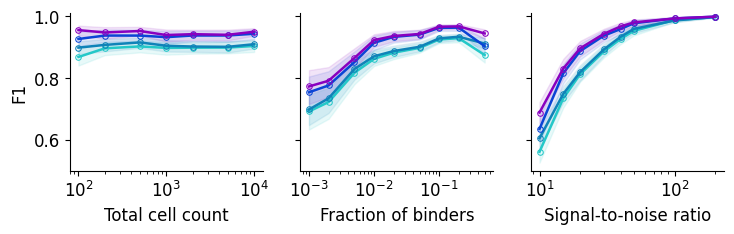

In [9]:
# Figure 2b - Classification performance stratified by simulation parameters
plt.figure(figsize=(2.5 * 3, 2.5))
i = 0
for parameter in ['sim_total_cells', 'sim_binding_ratio', 'sim_mean_inc']:
    df_sub = df_bench.copy()
    if parameter == 'sim_total_cells':
        # When stratifying by total cell count, we remove fraction of binder < 0.01, 
        # since 0.01 is the lowest value used for all total cell counts, 
        # as with ncells=100, we need binder_ratio>=0.01 to have >=1 binder
        df_sub = df_sub[df_sub['sim_binding_ratio'].between(0.01, 1)]    
    df_sub = df_sub[df_sub['model_config'] != 'BEAM']

    i += 1
    plt.subplot(1, 3, i)
    ax = sns.lineplot(df_sub, x=parameter, y='f1', hue='model_config', hue_order=hue_order, palette=palette, legend=False, 
                      linewidth=1.8, err_kws={'alpha': 0.1}, marker='.', markerfacecolor='none', markeredgecolor=None, markersize=8, ) 
    plt.xscale('log')
    plt.xlabel(naming_dict[parameter])
    if ax.get_legend():
        sns.move_legend(ax, 'upper left', bbox_to_anchor=(1, 1), frameon=False)
    plt.ylim(0.5, 1.01)
    plt.ylabel('F1' if i == 1 else '')
    plt.tick_params(labelleft=i==1)

    sns.despine()
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/Fig2b_synth_stratified.pdf')
plt.show()

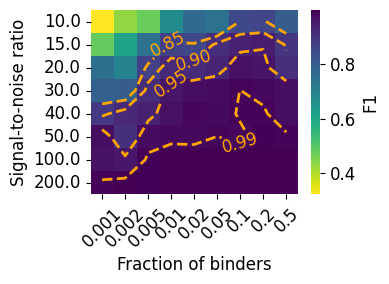

In [10]:
# Figure 2c - Heatmap with contour showing pairwise stratified performance
params = ['sim_mean_inc', 'sim_binding_ratio']
df_sub = df_bench.copy()
df_sub = df_sub[df_sub['model_config'] == 'DextraDemixer+neg.+clone']
means = df_sub.pivot_table(index=params[0], columns=params[1], values='f1')

# Heatmap
plt.figure(figsize=(4, 3))
ax = sns.heatmap( means, annot=False, fmt="", cmap='viridis_r', cbar_kws={'label': 'F1'} , )
x = np.arange(means.shape[1]) + 0.5
y = np.arange(means.shape[0]) + 0.5

# Contour
thresholds = np.array([0.85, 0.9, 0.95, 0.99])
contour = ax.contour(x, y, means.values, levels=thresholds, colors="orange", linewidths=2, linestyles='dashed')
ax.clabel(contour, inline=True, fontsize='medium', )
plt.xticks(rotation=45, ha='center')
plt.xlabel(naming_dict[params[1]])
plt.ylabel(naming_dict[params[0]])
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/Fig2c_synth_heatmap_contour.pdf')
plt.show()

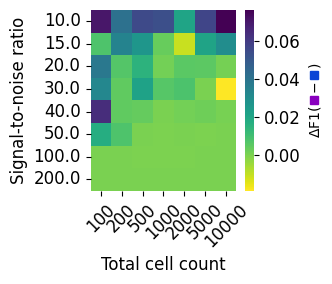

In [11]:
# Figure 2d -Difference between negative and non-negative stratified by SNR and Total cell count
params = ['sim_mean_inc', 'sim_total_cells']
df_sub = df_bench.copy()
df_sub = df_sub[df_sub['model_config'].isin([f'DextraDemixer+clone', f'DextraDemixer+neg.+clone'])]

pivot_table_neg = df_sub[df_sub['model_config'] == f'DextraDemixer+neg.+clone'].pivot_table(index=params[0], columns=params[1], values='f1')
pivot_table_no_neg = df_sub[df_sub['model_config'] == f'DextraDemixer+clone'].pivot_table(index=params[0], columns=params[1], values='f1')
diff = pivot_table_neg - pivot_table_no_neg

plt.figure(figsize=(3.5, 3))
ax = sns.heatmap( diff, annot=None, fmt=".2f", cmap='viridis_r', )
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel(r'$\Delta$F1(   $-$   )', fontsize='small')
cbar.ax.plot(7.6, 0.5, marker='s', color=palette["DextraDemixer+neg.+clone"], transform=cbar.ax.transAxes, clip_on=False, markersize=6, linestyle='None')
cbar.ax.plot(7.6, 0.64, marker='s', color=palette["DextraDemixer+clone"], transform=cbar.ax.transAxes, clip_on=False, markersize=6, linestyle='None')
plt.xticks(rotation=45, ha='center')
plt.xlabel(naming_dict[params[1]])
plt.ylabel(naming_dict[params[0]])
plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/Fig2d_synth_heatmap_neg_control.pdf')
plt.show()

## FDR control

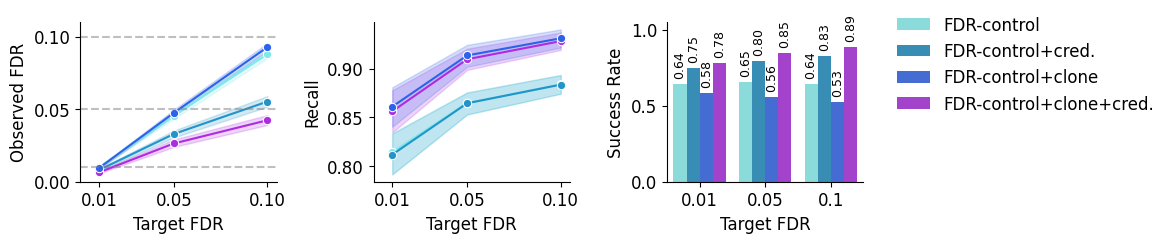

In [12]:
# Figure 2h-j - FDR control h) Observed FDR, i) Recall, j) Success rate (proportion of runs where observed FDR is below target FDR)
palette_fdr = {'FDR-control': "#7de9e9", 'FDR-control+cred.': "#2394c9", 'FDR-control+clone': "#2D62EA", 'FDR-control+clone+cred.': "#ad2be1"}
hue_order_fdr = ['FDR=0.01', 'FDR=0.01,cred_intvl=0.5', 'FDR=0.05', 'FDR=0.05,cred_intvl=0.5', 'FDR=0.1', 'FDR=0.1,cred_intvl=0.5', 'median@FDR=0.01', 
                 'median@FDR=0.01,cred_intvl=0.5', 'median@FDR=0.05', 'median@FDR=0.05,cred_intvl=0.5', 'median@FDR=0.1', 'median@FDR=0.1,cred_intvl=0.5', ]

df_sub = df_fdr.copy()
df_sub = df_sub[~(df_sub['model_config'] == 'BEAM')]
df_sub = df_sub[df_sub['model_neg_ctrl_key'] == 'neg_control']
df_sub = df_sub[df_sub['posterior_config_clean'].isin(hue_order_fdr)]
# Remove sets where number of binders is lower than the inverse target FDR, as one false positive would already exceed target FDR
df_sub = df_sub[(df_sub['sim_num_binder'] > 1/df_sub['target_fdr'])]  
df_sub['fdr_config_clean'] = 'FDR-control' + df_sub['posterior_config_clean'].str.contains('median').map({True: '+clone', False: ''}) + df_sub['cred_intvl'].notna().map({True: f'+cred.', False: ''})

####### Figure
fig = plt.figure(figsize=(9, 2.5))

# Observed FDR
plt.subplot(1, 3, 1)
ax = sns.lineplot(df_sub, x='target_fdr', y='fdr', hue='fdr_config_clean', palette=palette_fdr, marker='o', legend=False)
plt.xlim(0, 0.105)
plt.ylim(0, 0.11)
plt.xlabel('Target FDR')
plt.ylabel('Observed FDR')
plt.axhline(0.01, color='grey', linestyle='dashed', label='FDR=0.01', alpha=0.5)
plt.axhline(0.05, color='grey', linestyle='dashed', label='FDR=0.05', alpha=0.5)
plt.axhline(0.1, color='grey', linestyle='dashed', label='FDR=0.1', alpha=0.5)
plt.xticks([0.01, 0.05, 0.1])

# Recall
plt.subplot(1, 3, 2)
ax = sns.lineplot(df_sub, x='target_fdr', y='recall', hue='fdr_config_clean', palette=palette_fdr, marker='o', legend=False)
plt.xlim(0, 0.105)
plt.xlabel('Target FDR')
plt.ylabel('Recall')
plt.xticks([0.01, 0.05, 0.1])

# Success rate
df_sub['is_below_target'] = df_sub['fdr'] <= df_sub['target_fdr']
df_sub_gb = df_sub.groupby(['target_fdr', 'fdr_config_clean'], observed=True)['is_below_target'].mean().reset_index(name='Success Rate')
plt.subplot(1, 3, 3)
ax = sns.barplot(data=df_sub_gb, x='target_fdr', y='Success Rate', hue='fdr_config_clean', hue_order=palette_fdr.keys(), palette=palette_fdr, legend=True )
ax.set_xlabel('Target FDR')
plt.ylim(0, 1.05)
for c in ax.containers:
    labels = [f'{v.get_height():.2f}' if pd.notna(v.get_height()) and v.get_height() > 0 else '' for v in c]
    ax.bar_label(c, labels=labels, label_type='edge', padding=4, rotation=90, fontsize=9)


# Legend on the right side
handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.0, 1.0), ncol=1, frameon=False, title="", fontsize='medium')

plt.tight_layout()
plt.savefig(f'{FIGURE_PATH}/Fig2h-j_synth_fdr_control.pdf', bbox_inches='tight')
plt.show()

# Scaling analysis

In [13]:
from matplotlib.lines import Line2D
from scipy.stats import linregress


df_scaling = aggregate_csv(rerun=RERUN, experiment_path='benchmarks/scaling', output_path=os.path.join(RESULTS_PATH, 'results_scaling.csv'), paths=['csv'])
df_scaling['model_config_clean'] = df_scaling['model_neg_ctrl_key'].fillna('base').map({'base': 'DextraDemixer(+clone)', 'neg_control': 'DextraDemixer+neg.(+clone)'})
print('The following CPU models were used:', df_scaling['cpu_model'].unique())

The following CPU models were used: ['Intel(R) Xeon(R) Gold 6142M CPU @ 2.60GHz']


#### Runtime

In [14]:
fits = df_scaling.groupby("model_config_clean").apply(lambda g: linregress(g["sim_total_cells"], g["total_time"]))
fit_base, fit_neg = fits['DextraDemixer(+clone)'], fits['DextraDemixer+neg.(+clone)']

/tmp/ipykernel_4032627/2311869785.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fits = df_scaling.groupby("model_config_clean").apply(lambda g: linregress(g["sim_total_cells"], g["total_time"]))


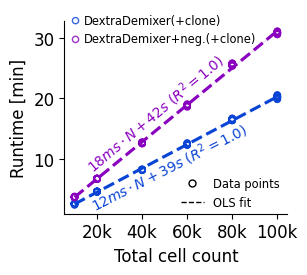

In [15]:
# Figure 2f - Runtime scaling with total cell count
df_sub = df_scaling.copy()
df_sub = df_sub[df_sub['sim_total_cells'].isin([10000, 20000, 40000, 60000, 80000, 100000])]
df_sub['total_time_min'] = df_sub['total_time'] / 60
g = sns.lmplot(df_sub, x='sim_total_cells', y='total_time_min', hue='model_config_clean', markers='o', palette=palette, 
                height=2.8, aspect=1.3,
                line_kws={'linestyle': '--',},
                scatter_kws={'facecolors': 'none', 'edgecolors': None, 's': 20},
        )
sns.move_legend(g, "upper right", bbox_to_anchor=(0.5, 1), title='', fontsize='x-small', handletextpad=-0.3)

sns.despine()
plt.text(x=16000, y=1.5, s=fr'${fit_base.slope*1000:.0f}ms \cdot N + {fit_base.intercept:.0f}s\ (R^{2}={fit_base.rvalue:.1f})$', fontsize=10, rotation=27, color=palette['DextraDemixer(+clone)'])
plt.text(x=14000, y=7.9, s=fr'${fit_neg.slope*1000:.0f}ms \cdot N + {fit_neg.intercept:.0f}s\ (R^{2}={fit_neg.rvalue:.1f})$', fontsize=10, rotation=40, color=palette['DextraDemixer+neg.(+clone)'])

plt.xlabel('Total cell count')
plt.ylabel('Runtime [min]')
plt.xticks([20000, 40000, 60000, 80000, 100000], labels=['20k', '40k', '60k', '80k', '100k'])

style_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='black', markersize=5, label='Data points'),
    Line2D([0], [0], linestyle='--', color='black', linewidth=1, label='OLS fit'),
]
g.ax.legend(handles=style_handles, loc=(0.5, 0.), fontsize='x-small', frameon=False)

plt.savefig(f'{FIGURE_PATH}/Fig2f_scaling_time.pdf')
plt.show()

#### Memory

In [16]:
fits = df_scaling.groupby("model_config_clean").apply(lambda g: linregress(g["sim_total_cells"], g["peak_mem_resource"]))
fit_base, fit_neg = fits['DextraDemixer(+clone)'], fits['DextraDemixer+neg.(+clone)']

/tmp/ipykernel_4032627/1370476265.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fits = df_scaling.groupby("model_config_clean").apply(lambda g: linregress(g["sim_total_cells"], g["peak_mem_resource"]))


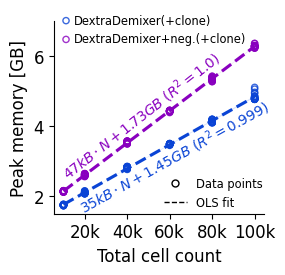

In [17]:
# Figure 2g - Peak memory scaling with total cell count
df_sub = df_scaling.copy()
df_sub = df_sub[df_sub['sim_total_cells'].isin([10000, 20000, 40000, 60000, 80000, 100000])]
df_sub['peak_mem_resource'] = df_sub['peak_mem_resource'] / 1024
g = sns.lmplot(df_sub, x='sim_total_cells', y='peak_mem_resource', hue='model_config_clean', markers='o', height=2.8, aspect=1.2, palette=palette,
                line_kws={'linestyle': '--',}, scatter_kws={'facecolors': 'none', 'edgecolors': None, 's': 20},)
sns.move_legend(g, "upper right", bbox_to_anchor=(0.5, 1), title='', fontsize='x-small', handletextpad=-0.3)

plt.text(x=16000, y=1.52, s=fr'${fit_base.slope*1000:.0f}kB \cdot N + {fit_base.intercept/1000:.2f}GB\ (R^{2}={fit_base.rvalue:.3f})$', fontsize=10, rotation=29, color=palette['DextraDemixer(+clone)'])
plt.text(x=8000, y=2.5, s=fr'${fit_neg.slope*1000:.0f}kB \cdot N + {fit_neg.intercept/1000:.2f}GB\ (R^{2}={fit_neg.rvalue:.1f})$', fontsize=10, rotation=38, color=palette['DextraDemixer+neg.(+clone)'])
plt.xlabel('Total cell count')
plt.ylabel('Peak memory [GB]')
plt.xticks([20000, 40000, 60000, 80000, 100000], labels=['20k', '40k', '60k', '80k', '100k'])
plt.ylim(1.5, 7)

style_handles = [
    Line2D([0], [0], marker='o', linestyle='None', markerfacecolor='none', markeredgecolor='black', markersize=5, label='Data points'),
    Line2D([0], [0], linestyle='--', color='black', linewidth=1, label='OLS fit'),
]
g.ax.legend(handles=style_handles, loc=(0.5, 0.), fontsize='x-small', frameon=False)
plt.savefig(f'{FIGURE_PATH}/Fig2g_scaling_mem.pdf')
plt.show()

# Clone dropout

In [18]:
df_dropout = aggregate_csv(rerun=RERUN, experiment_path='benchmarks/dropout', output_path=os.path.join(RESULTS_PATH, 'results_dropout.csv'), paths=['csv'])                                                              

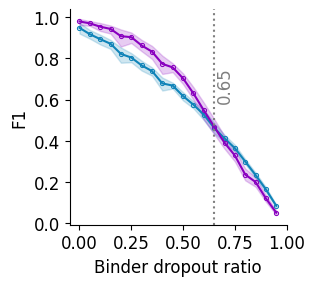

In [19]:
# Figure 2e - Sensitivity to binder dropout ratio
df_sub = df_dropout[df_dropout['threshold'] == 0.5].copy()

plt.figure(figsize=(2.8, 2.8))
ax = sns.lineplot(data=df_sub, x='sim_p_binding_outlier', y='f1', hue='model_config', legend=False,            
                  marker='.', markerfacecolor='none', markeredgecolor=None, palette=palette)
plt.xticks([0, 0.25, 0.5, 0.75, 1.0])
plt.axvline(0.65, ls=':', c='grey')
plt.text(0.66, 0.6, '0.65', fontsize='medium', color='grey', rotation=90)
plt.xlabel('Binder dropout ratio')
plt.ylabel('F1')
sns.despine()

plt.savefig(f'{FIGURE_PATH}/Fig2e_dropout_sensitivity.pdf')
plt.show()
